<a href="https://colab.research.google.com/github/achasinavas/Taller_de_Programacion_UBA/blob/main/TP3/TP3_Programacion_Grupo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP3 - Taller de Programación UBA  
## Grupo 2 - Clasificación de informalidad en la EPH

- Se construye una extensión tipo Maurizio y Monsalvo agregando el estatus de informalidad del año anterior para personas observadas en ambos años.


In [4]:
# ============================================================
# Celda 1 - Instalación e importación de paquetes
# ============================================================

!pip -q install openpyxl

import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

import statsmodels.api as sm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

print("Paquetes cargados correctamente.")


Paquetes cargados correctamente.


In [5]:
# ============================================================
# Celda 2 - Conexión a Drive y rutas de trabajo
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

# Ajustar esta ruta si los archivos están en otra carpeta.
ruta_drive = "/content/drive/MyDrive/taller_de_programacion/"

archivo_2024 = ruta_drive + "usu_individual_T424.xlsx"
archivo_2025 = ruta_drive + "usu_individual_T425.xlsx"

ruta_salidas = ruta_drive + "salidas_tp3/"
ruta_figuras = ruta_salidas + "figuras/"
ruta_tablas = ruta_salidas + "tablas/"

os.makedirs(ruta_salidas, exist_ok=True)
os.makedirs(ruta_figuras, exist_ok=True)
os.makedirs(ruta_tablas, exist_ok=True)

print("Ruta de entrada:", ruta_drive)
print("Ruta de salida:", ruta_salidas)

%cd /content

!git clone https://github.com/achasinavas/Taller_de_Programacion_UBA.git
%cd /content/Taller_de_Programacion_UBA


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ruta de entrada: /content/drive/MyDrive/taller_de_programacion/
Ruta de salida: /content/drive/MyDrive/taller_de_programacion/salidas_tp3/
/content
fatal: destination path 'Taller_de_Programacion_UBA' already exists and is not an empty directory.
/content/Taller_de_Programacion_UBA


In [6]:
# ============================================================
# Celda 3 - Carga de bases EPH
# ============================================================

eph24 = pd.read_excel(archivo_2024)
eph25 = pd.read_excel(archivo_2025)

# Normalizar nombres de columnas
eph24.columns = eph24.columns.astype(str).str.strip().str.upper()
eph25.columns = eph25.columns.astype(str).str.strip().str.upper()

print("Base 2024:", eph24.shape)
print("Base 2025:", eph25.shape)

display(eph24.head())


Base 2024: (46860, 235)
Base 2025: (43703, 235)


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,CH03,CH04,CH05,CH06,CH07,CH08,CH09,CH10,CH11,CH12,CH13,CH14,CH15,CH15_COD,CH16,CH16_COD,NIVEL_ED,ESTADO,CAT_OCUP,CAT_INAC,IMPUTA,PP02C1,PP02C2,PP02C3,PP02C4,PP02C5,PP02C6,PP02C7,PP02C8,PP02E,PP02H,PP02I,PP03C,PP03D,PP3E_TOT,PP3F_TOT,PP03G,PP03H,PP03I,PP03J,INTENSI,PP04A,PP04B_COD,PP04B1,PP04B2,PP04B3_MES,PP04B3_ANO,PP04B3_DIA,PP04C,PP04C99,PP04D_COD,PP04G,PP05B2_MES,PP05B2_ANO,PP05B2_DIA,PP05C_1,PP05C_2,PP05C_3,PP05E,PP05F,PP05H,PP06A,PP06C,PP06D,PP06E,...,IDECIFR,RDECIFR,GDECIFR,PDECIFR,ADECIFR,IPCF,DECCFR,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PONDIH,V2_02_M,V2_03_M,V5_03_M,V11_02_M,PP07B1_01,EMPLEO,SECTOR,PP02A,PP02B,PP02D,PP02F,PP02G,PP03K,PP04A1,PP05B3,PP05I,PP05J,PP05K,PP06E1,PP06K,PP06K_SEM,PP06K_MES,PP06L,PP07F1_1,PP07F1_2,PP07F1_3,PP07I2,PP07I3,PP07I4,PP07L,PP07M,PP08G,PP08G_DSEM,PP08G_DMES,PP08H,PP10B1,PP10B2,PP10B3,PP10B4,PP10B5,PP10B6,PP10B7,PP10B8,PP10B9,PP10B10,PP11L2,V2_01_M,V5_01_M,V5_02_M,V11_01_M,V21_01_M,V21_02_M,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNORTSHJKLMCDEHPJB00872828,2024,4,1,2,1,40,S,29,384,2,1,1945-03-22 00:00:00,79,2,1,1,2,0,6,1,NaN,3,6.0000,1,NaN,6,3,0,1,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0000,7,6.0000,NaN,7,"539,000.0000",7,8.0000,9,7.0000,NaN,9,586,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220000,0,0,0,0,0,0,70000,0,0,8.0000,9.0000,8.0000,NaN,8.0000,10.0000
1,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,1,1,40,S,29,265,1,2,2001-11-05 00:00:00,23,5,1,1,1,1,7,2,2.0000,3,66.0000,1,NaN,5,3,0,3,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0000,12,12.0000,NaN,12,0.0000,12,12.0000,12,12.0000,NaN,12,0,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,2,1,40,S,29,265,10,2,2004-03-02 00:00:00,20,5,4,1,1,1,7,2,0.0000,3,66.0000,1,NaN,5,3,0,3,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0000,12,12.0000,NaN,12,0.0000,12,12.0000,12,12.0000,NaN,12,0,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,-9,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,1,1,40,S,29,380,1,1,1994-01-21 00:00:00,30,1,1,1,2,0,6,1,NaN,3,66.0000,1,NaN,6,1,3,0,NaN,0,0,0,0,0,0,0,0,0,0,0,1.0000,0.0000,70.0000,0.0000,2.0000,0.0000,2.0000,2.0000,3.0000,2.0000,700.0000,2.0000,0.0000,0.0000,0.0000,0.0000,9.0000,0.0000,"70,313.0000",5.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,8.0000,9,7.0000,NaN,9,"750,000.0000",8,9.0000,10,8.0000,NaN,10,562,0,0,0,0,2.0000,1.0000,1.0000,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,2.0000,2.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,7.0000,0.0000,10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,9.0000,10.0000,9.0000,NaN,9.0000,10.0000
4,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,2,1,40,S,29,380,2,2,1994-02-14 00:00:00,30,1,1,1,2,0,6,1,NaN,3,66.0000,1,NaN,6,1,3,0,NaN,0,0,0,0,0,0,0,0,0,0,0,1.0000,0.0000,30.0000,0.0000,2.0000,0.0000,2.0000,2.0000,2.0000,2.0000,"8,200.0000",2.0000,0.0000,0.0000,0.0000,0.0000,12.0000,0.0000,"35,333.0000",11.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0

In [7]:
# ============================================================
# Celda 4 - Selección de variables TP1 + TP2
# ============================================================

variables_id = [
    "CODUSU",
    "ANO4",
    "TRIMESTRE",
    "NRO_HOGAR",
    "COMPONENTE",
    "PONDERA"
]

variables_tp1 = [
    "AGLOMERADO",
    "REGION",
    "CH03",
    "CH04",
    "CH06",
    "CH07",
    "CH08",
    "NIVEL_ED",
    "ESTADO",
    "CAT_OCUP",
    "EMPLEO",
    "SECTOR",
    "PP04C",
    "PP04D_COD",
    "PP07H",
    "PP07I",
    "PP07J",
    "PP07K",
    "PP08D1",
    "PP08F1",
    "P21",
    "P47T"
]

variables_tp2 = [
    "CH12",
    "CH13",
    "CH14",
    "PP3E_TOT",
    "PP3F_TOT"
]

variables = variables_id + variables_tp1 + variables_tp2

faltantes_2024 = [v for v in variables if v not in eph24.columns]
faltantes_2025 = [v for v in variables if v not in eph25.columns]

print("Variables faltantes en 2024:", faltantes_2024)
print("Variables faltantes en 2025:", faltantes_2025)

if len(faltantes_2024) > 0 or len(faltantes_2025) > 0:
    raise ValueError("Hay variables faltantes. Revisar nombres en las bases antes de continuar.")

eph24 = eph24[variables].copy()
eph25 = eph25[variables].copy()

print("Variables seleccionadas correctamente.")
print("Cantidad de variables:", len(variables))


Variables faltantes en 2024: []
Variables faltantes en 2025: []
Variables seleccionadas correctamente.
Cantidad de variables: 33


In [8]:
# ============================================================
# Celda 5 - Armonización y limpieza inicial
# ============================================================

# CODUSU queda como identificador de texto; el resto se convierte a numérico.
for df in [eph24, eph25]:
    df["CODUSU"] = df["CODUSU"].astype(str)

    for col in df.columns:
        if col != "CODUSU":
            df[col] = pd.to_numeric(df[col], errors="coerce")

# Limpieza de ingresos negativos: se consideran no respuesta/codificación no válida.
for df in [eph24, eph25]:
    for col in ["P21", "P47T"]:
        df.loc[df[col] < 0, col] = np.nan

# Limpieza de horas trabajadas: no se admiten valores negativos ni mayores a 168 horas semanales.
for df in [eph24, eph25]:
    for col in ["PP3E_TOT", "PP3F_TOT"]:
        df.loc[df[col] < 0, col] = np.nan
        df.loc[df[col] > 168, col] = np.nan

# Limpieza básica de PP04C: conservar códigos esperados de tamaño de establecimiento.
for df in [eph24, eph25]:
    df.loc[~df["PP04C"].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]), "PP04C"] = np.nan

# Agregar año
eph24["anio"] = 2024
eph25["anio"] = 2025

# Unir bases
base = pd.concat([eph24, eph25], ignore_index=True)

print("Base unificada:", base.shape)
display(base["anio"].value_counts())


Base unificada: (90563, 34)


,count
anio,
2024,46860
2025,43703


In [9]:
# ============================================================
# Celda 6 - Ajuste de ingresos 2024 a pesos de 2025
# ============================================================

# Factor usado en TP1/TP2: 31,5% acumulado.
FACTOR_ACTUALIZACION_2024_A_2025 = 1.315

base["P21_original"] = base["P21"]
base["P47T_original"] = base["P47T"]

base.loc[base["anio"] == 2024, "P21"] = (
    base.loc[base["anio"] == 2024, "P21"] * FACTOR_ACTUALIZACION_2024_A_2025
)

base.loc[base["anio"] == 2024, "P47T"] = (
    base.loc[base["anio"] == 2024, "P47T"] * FACTOR_ACTUALIZACION_2024_A_2025
)

print("Ingresos de 2024 actualizados a pesos de 2025.")
print("Factor aplicado:", FACTOR_ACTUALIZACION_2024_A_2025)


Ingresos de 2024 actualizados a pesos de 2025.
Factor aplicado: 1.315


In [10]:
# ============================================================
# Celda 7 - Reconstrucción de bases TP1
# ============================================================

respondieron = base[base["ESTADO"] != 0].copy()
norespondieron = base[base["ESTADO"] == 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

print("Base completa:", base.shape)
print("Respondieron:", respondieron.shape)
print("No respondieron:", norespondieron.shape)
print("Ocupados:", ocupados.shape)

display(norespondieron.groupby("anio").size().reset_index(name="no_respondieron"))
display(ocupados.groupby("anio").size().reset_index(name="ocupados"))


Base completa: (90563, 36)
Respondieron: (90442, 36)
No respondieron: (121, 36)
Ocupados: (40830, 36)


,anio,no_respondieron
0,2024,56
1,2025,65


,anio,ocupados
0,2024,21132
1,2025,19698


In [11]:
# ============================================================
# Celda 8 - Creación de variables TP2
# edad, edad2, educ, horastrabj, nhogar
# ============================================================

# Edad y edad al cuadrado
base["edad"] = base["CH06"]
base["edad2"] = base["edad"] ** 2

# Años de educación formal aproximados con CH12, CH13 y CH14
def calcular_educacion(row):
    nivel = row["CH12"]
    finalizo = row["CH13"]
    ultimo = row["CH14"]

    if pd.isna(nivel):
        return np.nan

    if pd.isna(ultimo) or ultimo in [98, 99]:
        ultimo = np.nan

    # Años completos aproximados por máximo nivel educativo finalizado.
    anios_completos = {
        1: 0,     # Jardín / preescolar
        2: 6,     # Primario
        3: 9,     # EGB
        4: 12,    # Secundario
        5: 12,    # Polimodal
        6: 15,    # Terciario
        7: 17,    # Universitario
        8: 19,    # Posgrado
        9: np.nan
    }

    # Base acumulada para niveles no finalizados.
    base_incompleta = {
        1: 0,
        2: 0,
        3: 0,
        4: 6,
        5: 9,
        6: 12,
        7: 12,
        8: 17,
        9: np.nan
    }

    # Máximo de años posibles dentro del nivel.
    max_anio_nivel = {
        1: 0,
        2: 6,
        3: 9,
        4: 6,
        5: 3,
        6: 4,
        7: 6,
        8: 2,
        9: np.nan
    }

    if finalizo == 1:
        return anios_completos.get(nivel, np.nan)

    if finalizo == 2:
        base_prev = base_incompleta.get(nivel, np.nan)
        max_nivel = max_anio_nivel.get(nivel, np.nan)

        if pd.isna(base_prev):
            return np.nan

        if pd.isna(ultimo):
            return base_prev

        ultimo = max(0, min(ultimo, max_nivel))
        return base_prev + ultimo

    return np.nan

base["educ"] = base.apply(calcular_educacion, axis=1)

# Horas trabajadas individuales
base["horastrab_individual"] = base["PP3E_TOT"].fillna(0) + base["PP3F_TOT"].fillna(0)

ambas_horas_na = base["PP3E_TOT"].isna() & base["PP3F_TOT"].isna()
base.loc[ambas_horas_na, "horastrab_individual"] = np.nan

# Identificador de hogar
base["hogar_id"] = (
    base["CODUSU"].astype(str)
    + "_"
    + base["NRO_HOGAR"].astype("Int64").astype(str)
    + "_"
    + base["anio"].astype(str)
)

# Identificador de persona para la unión 2024-2025
# No incluye año porque se busca la misma persona entre años.
base["persona_id"] = (
    base["CODUSU"].astype(str)
    + "_"
    + base["NRO_HOGAR"].astype("Int64").astype(str)
    + "_"
    + base["COMPONENTE"].astype("Int64").astype(str)
)

# Horas trabajadas por el jefe del hogar
jefes = (
    base[base["CH03"] == 1]
    .groupby("hogar_id", as_index=False)["horastrab_individual"]
    .mean()
    .rename(columns={"horastrab_individual": "horastrabj"})
)

base = base.merge(jefes, on="hogar_id", how="left")

# Número de miembros del hogar
nhogar = (
    base.groupby("hogar_id", as_index=False)["COMPONENTE"]
    .nunique()
    .rename(columns={"COMPONENTE": "nhogar"})
)

base = base.merge(nhogar, on="hogar_id", how="left")

# Recrear bases después de agregar variables TP2
respondieron = base[base["ESTADO"] != 0].copy()
norespondieron = base[base["ESTADO"] == 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

print("Variables TP2 creadas correctamente.")
display(ocupados[["anio", "edad", "edad2", "educ", "horastrab_individual", "horastrabj", "nhogar"]].head())


Variables TP2 creadas correctamente.


,anio,edad,edad2,educ,horastrab_individual,horastrabj,nhogar
3,2024,30,900,15.0000,70.0000,70.0000,2
4,2024,30,900,15.0000,30.0000,70.0000,2
5,2024,44,1936,15.0000,49.0000,49.0000,5
6,2024,46,2116,19.0000,40.0000,49.0000,5
10,2024,36,1296,17.0000,32.0000,32.0000,3


In [12]:
# ============================================================
# Celda 9 - Dummies TP1 e informalidad Grupo 2
# ============================================================

ocupados["mujer"] = (ocupados["CH04"] == 2).astype(int)
ocupados["hombre"] = (ocupados["CH04"] == 1).astype(int)

ocupados["casado_unido"] = ocupados["CH07"].isin([1, 2]).astype(int)
ocupados["universitario"] = (ocupados["NIVEL_ED"] >= 6).astype(int)
ocupados["asalariado"] = (ocupados["CAT_OCUP"] == 3).astype(int)
ocupados["tiene_cobertura_salud"] = (~ocupados["CH08"].isin([4, 9])).astype(int)

ocupados["empresa_hasta_5"] = ocupados["PP04C"].isin([1, 2, 3, 4, 5]).astype(int)
ocupados["empresa_mas_5"] = ocupados["PP04C"].isin([6, 7, 8, 9, 10, 11, 12]).astype(int)

ocupados["con_descuento_jubilatorio"] = (ocupados["PP07H"] == 1).astype(int)
ocupados["sin_descuento_jubilatorio"] = (ocupados["PP07H"] == 2).astype(int)

# Definición asignada al Grupo 2:
# Upper-tier informal wage employees.
ocupados["informal"] = (
    (ocupados["CAT_OCUP"] == 3) &
    (ocupados["PP07H"] == 2) &
    (ocupados["empresa_mas_5"] == 1)
).astype(int)

ocupados["formal"] = (ocupados["informal"] == 0).astype(int)

ocupados["condicion_laboral"] = np.where(
    ocupados["informal"] == 1,
    "Informal Grupo 2",
    "No informal Grupo 2"
)

print("Distribución de informalidad Grupo 2:")
display(
    ocupados.groupby(["anio", "condicion_laboral"])
    .size()
    .reset_index(name="n")
)


Distribución de informalidad Grupo 2:


,anio,condicion_laboral,n
0,2024,Informal Grupo 2,1578
1,2024,No informal Grupo 2,19554
2,2025,Informal Grupo 2,1377
3,2025,No informal Grupo 2,18321


## A. Enfoque de validación: 2024 como entrenamiento y 2025 como testeo

Se construyen las matrices:
- `ocupados_X_2024`: variables de características para entrenamiento.
- `ocupados_X_2025`: variables de características para testeo.
- `y_2024`: variable objetivo de informalidad en 2024.
- `y_2025`: variable objetivo de informalidad en 2025.
- `ocupados_X_2025_MM`: matriz 2025 con una columna adicional `informal_2024`, construida mediante una unión por intersección de personas observadas en ambos años.


In [13]:
# ============================================================
# Celda 10 - Construcción de matrices X e y
# ============================================================

features_base = [
    "edad",
    "edad2",
    "educ",
    "horastrabj",
    "nhogar",
    "P21",
    "PP04C",
    "mujer",
    "casado_unido",
    "tiene_cobertura_salud"
]

ids_persona = ["persona_id", "CODUSU", "NRO_HOGAR", "COMPONENTE"]

columnas_modelo = ids_persona + ["anio", "PONDERA", "informal"] + features_base

ocupados_modelo = ocupados[columnas_modelo].dropna().copy()

ocupados_2024 = ocupados_modelo[ocupados_modelo["anio"] == 2024].copy()
ocupados_2025 = ocupados_modelo[ocupados_modelo["anio"] == 2025].copy()

ocupados_X_2024 = ocupados_2024[features_base].copy()
ocupados_X_2025 = ocupados_2025[features_base].copy()

y_2024 = ocupados_2024["informal"].astype(int).copy()
y_2025 = ocupados_2025["informal"].astype(int).copy()

print("ocupados_X_2024:", ocupados_X_2024.shape)
print("ocupados_X_2025:", ocupados_X_2025.shape)
print("y_2024:", y_2024.shape)
print("y_2025:", y_2025.shape)

display(ocupados_X_2024.head())


ocupados_X_2024: (11789, 10)
ocupados_X_2025: (10849, 10)
y_2024: (11789,)
y_2025: (10849,)


,edad,edad2,educ,horastrabj,nhogar,P21,PP04C,mujer,casado_unido,tiene_cobertura_salud
3,30,900,15.0000,70.0000,2,"1,315,000.0000",9.0000,0,1,1
4,30,900,15.0000,70.0000,2,"657,500.0000",12.0000,1,1,1
5,44,1936,15.0000,49.0000,5,"3,287,500.0000",10.0000,0,1,1
6,46,2116,19.0000,49.0000,5,"2,761,500.0000",12.0000,1,1,1
10,36,1296,17.0000,32.0000,3,"1,183,500.0000",12.0000,0,1,1


In [14]:
# ============================================================
# Celda 11 - Construcción de ocupados_X_2025_MM
# Inner join 2025 con informalidad 2024 de la misma persona
# ============================================================

informal_2024 = (
    ocupados_2024[["persona_id", "informal"]]
    .rename(columns={"informal": "informal_2024"})
    .copy()
)

ocupados_2025_mm = ocupados_2025.merge(
    informal_2024,
    on="persona_id",
    how="inner"
)

features_mm = features_base + ["informal_2024"]

ocupados_X_2025_MM = ocupados_2025_mm[features_mm].copy()
y_2025_MM = ocupados_2025_mm["informal"].astype(int).copy()

print("Ocupados 2025 antes de unión:", ocupados_2025.shape[0])
print("Ocupados 2025_MM después de inner join:", ocupados_2025_mm.shape[0])
print("ocupados_X_2025_MM:", ocupados_X_2025_MM.shape)
print("y_2025_MM:", y_2025_MM.shape)

display(ocupados_X_2025_MM.head())


Ocupados 2025 antes de unión: 10849
Ocupados 2025_MM después de inner join: 3163
ocupados_X_2025_MM: (3163, 11)
y_2025_MM: (3163,)


,edad,edad2,educ,horastrabj,nhogar,P21,PP04C,mujer,casado_unido,tiene_cobertura_salud,informal_2024
0,30,900,12.0000,40.0000,3,"1,100,000.0000",11.0000,0,0,1,0
1,24,576,12.0000,40.0000,3,"1,200,000.0000",7.0000,0,0,1,0
2,58,3364,17.0000,45.0000,3,"2,500,000.0000",11.0000,1,0,1,0
3,25,625,17.0000,45.0000,3,"900,000.0000",11.0000,1,0,1,0
4,52,2704,8.0000,32.0000,4,"800,000.0000",9.0000,0,0,1,0


In [15]:
# ============================================================
# Celda 12 - Balance table train vs test sample
# Diferencia de medias 2024 vs 2025
# ============================================================

def balance_table(df_2024, df_2025, variables):
    filas = []

    for var in variables:
        x24 = df_2024[var].dropna()
        x25 = df_2025[var].dropna()

        media24 = x24.mean()
        media25 = x25.mean()
        diff = media25 - media24

        # Welch t-test
        tstat, pvalue = stats.ttest_ind(x25, x24, equal_var=False, nan_policy="omit")

        if pvalue < 0.01:
            sig = "***"
        elif pvalue < 0.05:
            sig = "**"
        elif pvalue < 0.10:
            sig = "*"
        else:
            sig = ""

        filas.append({
            "variable": var,
            "media_2024_train": media24,
            "media_2025_test": media25,
            "diferencia_2025_menos_2024": diff,
            "p_value": pvalue,
            "significancia": sig,
            "n_2024": len(x24),
            "n_2025": len(x25)
        })

    return pd.DataFrame(filas).round(4)

tabla_balance = balance_table(ocupados_X_2024, ocupados_X_2025, features_base)

display(tabla_balance)

tabla_balance.to_excel(
    ruta_tablas + "TP3_Balance_Table_Train_2024_vs_Test_2025.xlsx",
    index=False
)


,variable,media_2024_train,media_2025_test,diferencia_2025_menos_2024,p_value,significancia,n_2024,n_2025
0,edad,41.6253,42.2656,0.6403,0.0002,***,11789,10849
1,edad2,"1,900.2907","1,958.2267",57.9361,0.0002,***,11789,10849
2,educ,12.3000,12.2420,-0.0581,0.2269,,11789,10849
3,horastrabj,39.0690,39.6763,0.6072,0.0065,***,11789,10849
4,nhogar,3.3178,3.2865,-0.0314,0.1627,,11789,10849
5,P21,"912,092.4457","1,016,792.3712","104,699.9255",0.0000,***,11789,10849
6,PP04C,5.6862,5.4978,-0.1884,0.0001,***,11789,10849
7,mujer,0.4375,0.4472,0.0097,0.1420,,11789,10849
8,casado_unido,0.5727,0.5721,-0.0005,0.9363,,11789,10849
9,tiene_cobertura_salud,0.7438,0.7348,-0.0090,0.1228,,11789,10849


## B. Modelo de Regresión Logística

Se estiman dos modelos:
1. Modelo 2024: usa `ocupados_X_2024` para predecir `y_2024`.
2. Modelo MM: usa `ocupados_X_2025_MM` para predecir `y_2025`, incluyendo el estatus de informalidad observado en 2024.


In [16]:
# ============================================================
# Celda 13 - Funciones auxiliares para logit
# ============================================================

variables_continuas = [
    "edad",
    "edad2",
    "educ",
    "horastrabj",
    "nhogar",
    "P21",
    "PP04C"
]

variables_binarias = [
    "mujer",
    "casado_unido",
    "tiene_cobertura_salud"
]

def escalar_train_test(X_train, X_test, continuas):
    scaler = StandardScaler()

    X_train_out = X_train.copy()
    X_test_out = X_test.copy()

    X_train_out[continuas] = scaler.fit_transform(X_train_out[continuas])
    X_test_out[continuas] = scaler.transform(X_test_out[continuas])

    return X_train_out, X_test_out, scaler

def escalar_una_base(X, continuas):
    scaler = StandardScaler()
    X_out = X.copy()
    X_out[continuas] = scaler.fit_transform(X_out[continuas])
    return X_out, scaler

def ajustar_logit_glm(X, y, nombre_modelo):
    X_const = sm.add_constant(X, has_constant="add")

    modelo = sm.GLM(
        y,
        X_const,
        family=sm.families.Binomial()
    )

    resultado = modelo.fit()

    print(f"Modelo estimado: {nombre_modelo}")
    print(resultado.summary())

    return resultado

def tabla_resultados_logit(resultado, nombre_modelo):
    tabla = pd.DataFrame({
        "modelo": nombre_modelo,
        "variable": resultado.params.index,
        "coeficiente": resultado.params.values,
        "error_estandar": resultado.bse.values,
        "p_value": resultado.pvalues.values
    })

    tabla["odd_ratio"] = np.exp(tabla["coeficiente"])

    tabla["significancia"] = np.select(
        [
            tabla["p_value"] < 0.01,
            tabla["p_value"] < 0.05,
            tabla["p_value"] < 0.10
        ],
        ["***", "**", "*"],
        default=""
    )

    return tabla.round(4)


In [17]:
# ============================================================
# Celda 14 - Modelo 1: Logit entrenado con 2024
# ============================================================

X_train_2024_scaled, X_test_2025_scaled, scaler_modelo_2024 = escalar_train_test(
    ocupados_X_2024,
    ocupados_X_2025,
    variables_continuas
)

modelo_logit_2024 = ajustar_logit_glm(
    X_train_2024_scaled,
    y_2024,
    "Modelo 1 - Logit 2024"
)

tabla_logit_2024 = tabla_resultados_logit(modelo_logit_2024, "Modelo 1 - 2024")

display(tabla_logit_2024)


Modelo estimado: Modelo 1 - Logit 2024
                 Generalized Linear Model Regression Results                  
Dep. Variable:               informal   No. Observations:                11789
Model:                            GLM   Df Residuals:                    11778
Model Family:                Binomial   Df Model:                           10
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2622.9
Date:                Mon, 17 Aug 2026   Deviance:                       5245.7
Time:                        15:01:02   Pearson chi2:                 2.24e+05
No. Iterations:                     7   Pseudo R-squ. (CS):             0.1627
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

,modelo,variable,coeficiente,error_estandar,p_value,odd_ratio,significancia
0,Modelo 1 - 2024,const,-1.4684,0.0950,0.0000,0.2303,***
1,Modelo 1 - 2024,edad,-1.2631,0.2367,0.0000,0.2828,***
2,Modelo 1 - 2024,edad2,1.0927,0.2497,0.0000,2.9824,***
3,Modelo 1 - 2024,educ,-0.0796,0.0432,0.0654,0.9235,*
4,Modelo 1 - 2024,horastrabj,-0.0354,0.0371,0.3402,0.9653,
5,Modelo 1 - 2024,nhogar,-0.0426,0.0362,0.2397,0.9583,
6,Modelo 1 - 2024,P21,-1.3624,0.0910,0.0000,0.2560,***
7,Modelo 1 - 2024,PP04C,1.9268,0.0615,0.0000,6.8675,***
8,Modelo 1 - 2024,mujer,0.1501,0.0771,0.0517,1.1619,*
9,Modelo 1 - 2024,casado_unido,-0.0396,0.0804,0.6227,0.9612,


In [18]:
# ============================================================
# Celda 15 - Modelo 2: Logit MM con información de informalidad previa
# ============================================================

variables_continuas_mm = variables_continuas.copy()
variables_binarias_mm = variables_binarias + ["informal_2024"]

X_2025_MM_scaled, scaler_modelo_mm = escalar_una_base(
    ocupados_X_2025_MM,
    variables_continuas_mm
)

modelo_logit_mm = ajustar_logit_glm(
    X_2025_MM_scaled,
    y_2025_MM,
    "Modelo 2 - Logit MM 2025 con informalidad 2024"
)

tabla_logit_mm = tabla_resultados_logit(modelo_logit_mm, "Modelo 2 - MM")

display(tabla_logit_mm)


Modelo estimado: Modelo 2 - Logit MM 2025 con informalidad 2024
                 Generalized Linear Model Regression Results                  
Dep. Variable:               informal   No. Observations:                 3163
Model:                            GLM   Df Residuals:                     3151
Model Family:                Binomial   Df Model:                           11
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -506.97
Date:                Mon, 17 Aug 2026   Deviance:                       1013.9
Time:                        15:01:02   Pearson chi2:                 3.78e+03
No. Iterations:                     8   Pseudo R-squ. (CS):             0.1883
Covariance Type:            nonrobust                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

,modelo,variable,coeficiente,error_estandar,p_value,odd_ratio,significancia
0,Modelo 2 - MM,const,-2.1207,0.2344,0.0000,0.1200,***
1,Modelo 2 - MM,edad,-0.9095,0.5766,0.1147,0.4027,
2,Modelo 2 - MM,edad2,0.8764,0.6051,0.1476,2.4022,
3,Modelo 2 - MM,educ,0.0127,0.1022,0.9014,1.0127,
4,Modelo 2 - MM,horastrabj,0.1243,0.0816,0.1274,1.1324,
5,Modelo 2 - MM,nhogar,-0.0906,0.0846,0.2847,0.9134,
6,Modelo 2 - MM,P21,-1.3298,0.2096,0.0000,0.2645,***
7,Modelo 2 - MM,PP04C,1.9020,0.1462,0.0000,6.6990,***
8,Modelo 2 - MM,mujer,-0.1384,0.1856,0.4556,0.8707,
9,Modelo 2 - MM,casado_unido,0.0658,0.1954,0.7364,1.0680,


In [19]:
# ============================================================
# Celda 16 - Tabla comparativa de modelos logit
# coeficientes, errores estándar y odd-ratios
# ============================================================

tabla_modelos_logit = pd.concat(
    [tabla_logit_2024, tabla_logit_mm],
    ignore_index=True
)

display(tabla_modelos_logit)

tabla_modelos_logit.to_excel(
    ruta_tablas + "TP3_Tabla_Modelos_Logit_Coef_SE_OR.xlsx",
    index=False
)


,modelo,variable,coeficiente,error_estandar,p_value,odd_ratio,significancia
0,Modelo 1 - 2024,const,-1.4684,0.0950,0.0000,0.2303,***
1,Modelo 1 - 2024,edad,-1.2631,0.2367,0.0000,0.2828,***
2,Modelo 1 - 2024,edad2,1.0927,0.2497,0.0000,2.9824,***
3,Modelo 1 - 2024,educ,-0.0796,0.0432,0.0654,0.9235,*
4,Modelo 1 - 2024,horastrabj,-0.0354,0.0371,0.3402,0.9653,
5,Modelo 1 - 2024,nhogar,-0.0426,0.0362,0.2397,0.9583,
6,Modelo 1 - 2024,P21,-1.3624,0.0910,0.0000,0.2560,***
7,Modelo 1 - 2024,PP04C,1.9268,0.0615,0.0000,6.8675,***
8,Modelo 1 - 2024,mujer,0.1501,0.0771,0.0517,1.1619,*
9,Modelo 1 - 2024,casado_unido,-0.0396,0.0804,0.6227,0.9612,


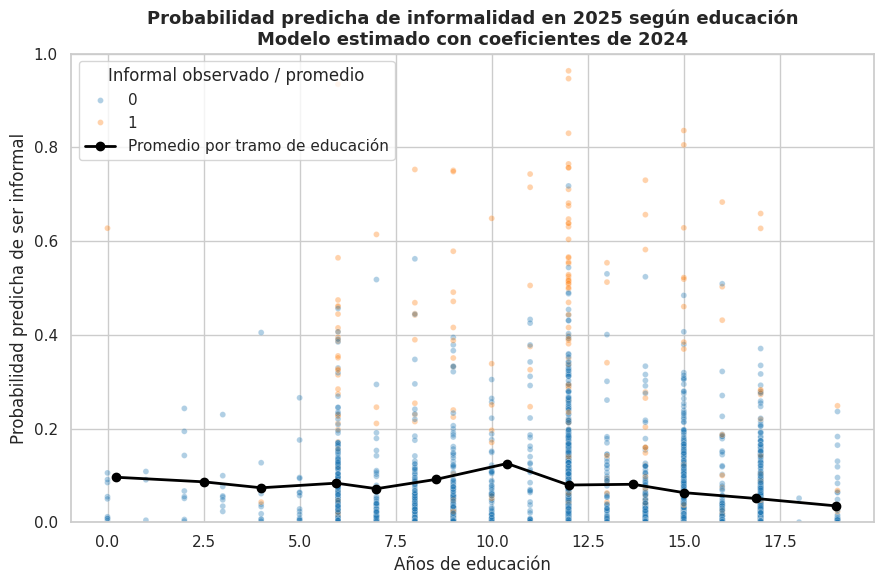

,educ_bin,educ_promedio,prob_promedio,informal_observada,n
0,"(-0.019, 1.583]",0.2308,0.0960,0.0769,13
1,"(1.583, 3.167]",2.5000,0.0863,0.0000,16
2,"(3.167, 4.75]",4.0000,0.0736,0.0909,11
3,"(4.75, 6.333]",5.9561,0.0834,0.1066,319
4,"(6.333, 7.917]",7.0000,0.0716,0.0545,55
5,"(7.917, 9.5]",8.5469,0.0914,0.1016,256
6,"(9.5, 11.083]",10.4020,0.1253,0.1275,102
7,"(11.083, 12.667]",12.0000,0.0795,0.0682,1055
8,"(12.667, 14.25]",13.6821,0.0810,0.1231,195
9,"(14.25, 15.833]",15.0000,0.0632,0.0489,532


In [20]:
# ============================================================
# Celda 17 - Probabilidades predichas en 2025 usando coeficientes de 2024
# P(Y25 = 1 | X_2025_MM)
# ============================================================

# Para usar coeficientes estimados en 2024 sobre la base 2025_MM,
# se usan las mismas variables base, sin incluir informal_2024.
X_2025_MM_base = ocupados_2025_mm[features_base].copy()

# Transformar X_2025_MM_base con el scaler ajustado en 2024.
X_2025_MM_base_scaled = X_2025_MM_base.copy()
X_2025_MM_base_scaled[variables_continuas] = scaler_modelo_2024.transform(
    X_2025_MM_base_scaled[variables_continuas]
)

X_2025_MM_base_scaled_const = sm.add_constant(
    X_2025_MM_base_scaled,
    has_constant="add"
)

ocupados_2025_mm["prob_pred_2024_en_2025"] = modelo_logit_2024.predict(
    X_2025_MM_base_scaled_const
)

# Gráfico: probabilidad predicha contra educación.
graf_prob = ocupados_2025_mm[
    ["educ", "prob_pred_2024_en_2025", "informal"]
].dropna().copy()

# Bins por educación para suavizar la visualización.
graf_prob["educ_bin"] = pd.cut(graf_prob["educ"], bins=12)

prob_por_educ = (
    graf_prob
    .groupby("educ_bin", as_index=False)
    .agg(
        educ_promedio=("educ", "mean"),
        prob_promedio=("prob_pred_2024_en_2025", "mean"),
        informal_observada=("informal", "mean"),
        n=("educ", "size")
    )
)

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=graf_prob.sample(n=min(6000, len(graf_prob)), random_state=123),
    x="educ",
    y="prob_pred_2024_en_2025",
    hue="informal",
    alpha=0.35,
    s=18,
    palette="tab10"
)

plt.plot(
    prob_por_educ["educ_promedio"],
    prob_por_educ["prob_promedio"],
    marker="o",
    linewidth=2,
    color="black",
    label="Promedio por tramo de educación"
)

plt.title(
    "Probabilidad predicha de informalidad en 2025 según educación\n"
    "Modelo estimado con coeficientes de 2024",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel("Años de educación")
plt.ylabel("Probabilidad predicha de ser informal")
plt.ylim(0, 1)
plt.legend(title="Informal observado / promedio")
plt.tight_layout()

plt.savefig(
    ruta_figuras + "TP3_Probabilidad_Predicha_Informalidad_vs_Educacion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(prob_por_educ.round(4))

In [34]:
prob_por_educ.round(4).to_excel(
    ruta_tablas + "TP3_Probabilidad_Predicha_por_Tramo_Educativo.xlsx",
    index=False
)

## C. Desempeño del modelo y predicción fuera de muestra

Se evalúan los dos modelos mediante:
- matriz de confusión con umbral `p > 0.5`;
- curva ROC;
- Accuracy;
- Precision;
- Recall;
- F1-score;
- AUC.


In [21]:
# ============================================================
# Celda 18 - Funciones de evaluación
# ============================================================

def evaluar_modelo(y_true, prob_pred, nombre_modelo, umbral=0.5):
    y_pred = (prob_pred > umbral).astype(int)

    matriz = confusion_matrix(y_true, y_pred)

    metricas = {
        "modelo": nombre_modelo,
        "umbral": umbral,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, prob_pred)
    }

    return matriz, pd.DataFrame([metricas]), y_pred

def graficar_matriz_confusion(matriz, titulo, archivo_salida):
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred. no informal", "Pred. informal"],
        yticklabels=["Obs. no informal", "Obs. informal"]
    )

    plt.title(titulo, fontsize=13, fontweight="bold")
    plt.xlabel("Predicción")
    plt.ylabel("Valor observado")
    plt.tight_layout()
    plt.savefig(archivo_salida, dpi=300, bbox_inches="tight")
    plt.show()


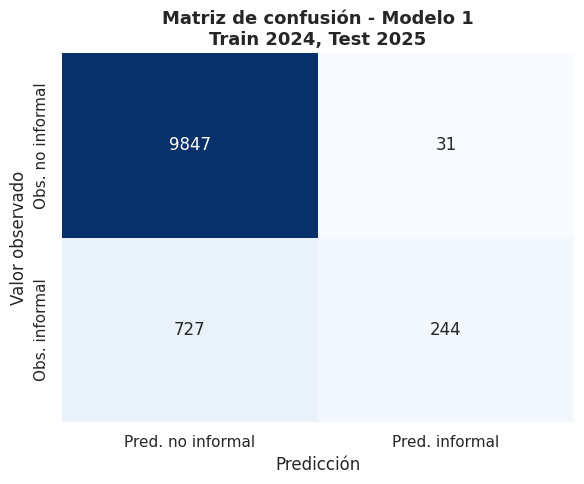

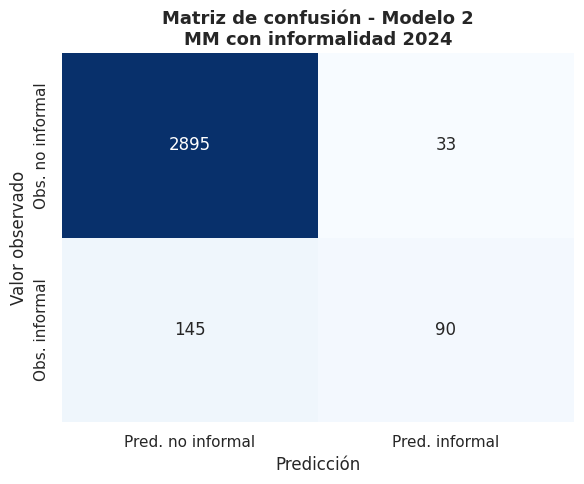

Classification report Modelo 1:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      9878
           1       0.89      0.25      0.39       971

    accuracy                           0.93     10849
   macro avg       0.91      0.62      0.68     10849
weighted avg       0.93      0.93      0.91     10849


Classification report Modelo 2:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97      2928
           1       0.73      0.38      0.50       235

    accuracy                           0.94      3163
   macro avg       0.84      0.69      0.74      3163
weighted avg       0.94      0.94      0.94      3163



,modelo,umbral,accuracy,precision,recall,f1_score,auc
0,Modelo 1 - Logit 2024 aplicado a 2025,0.5000,0.9301,0.8873,0.2513,0.3917,0.8342
1,Modelo 2 - Logit MM con informalidad 2024,0.5000,0.9437,0.7317,0.3830,0.5028,0.8895


In [22]:
# ============================================================
# Celda 19 - Predicciones 2025 y matrices de confusión
# ============================================================

# ------------------------------------------------------------
# Modelo 1: entrenado en 2024, evaluado sobre 2025
# ------------------------------------------------------------

X_test_2025_scaled_const = sm.add_constant(
    X_test_2025_scaled,
    has_constant="add"
)

prob_2025_modelo_2024 = modelo_logit_2024.predict(
    X_test_2025_scaled_const
)

matriz_m1, metricas_m1, y_pred_m1 = evaluar_modelo(
    y_2025,
    prob_2025_modelo_2024,
    "Modelo 1 - Logit 2024 aplicado a 2025",
    umbral=0.5
)

graficar_matriz_confusion(
    matriz_m1,
    "Matriz de confusión - Modelo 1\nTrain 2024, Test 2025",
    ruta_figuras + "TP3_Matriz_Confusion_Modelo1.png"
)

# ------------------------------------------------------------
# Modelo 2: modelo MM evaluado sobre la base 2025_MM
# ------------------------------------------------------------

X_2025_MM_scaled_const = sm.add_constant(
    X_2025_MM_scaled,
    has_constant="add"
)

prob_2025_modelo_mm = modelo_logit_mm.predict(
    X_2025_MM_scaled_const
)

matriz_m2, metricas_m2, y_pred_m2 = evaluar_modelo(
    y_2025_MM,
    prob_2025_modelo_mm,
    "Modelo 2 - Logit MM con informalidad 2024",
    umbral=0.5
)

graficar_matriz_confusion(
    matriz_m2,
    "Matriz de confusión - Modelo 2\nMM con informalidad 2024",
    ruta_figuras + "TP3_Matriz_Confusion_Modelo2_MM.png"
)

# ------------------------------------------------------------
# Reportes de clasificación
# ------------------------------------------------------------

print("Classification report Modelo 1:")
print(
    classification_report(
        y_2025,
        y_pred_m1,
        zero_division=0
    )
)

print("\nClassification report Modelo 2:")
print(
    classification_report(
        y_2025_MM,
        y_pred_m2,
        zero_division=0
    )
)

# ------------------------------------------------------------
# Tabla de métricas comparativas
# ------------------------------------------------------------

metricas_modelos = pd.concat(
    [metricas_m1, metricas_m2],
    ignore_index=True
)

display(metricas_modelos.round(4))

metricas_modelos.to_excel(
    ruta_tablas + "TP3_Metricas_Modelos_Logit.xlsx",
    index=False
)

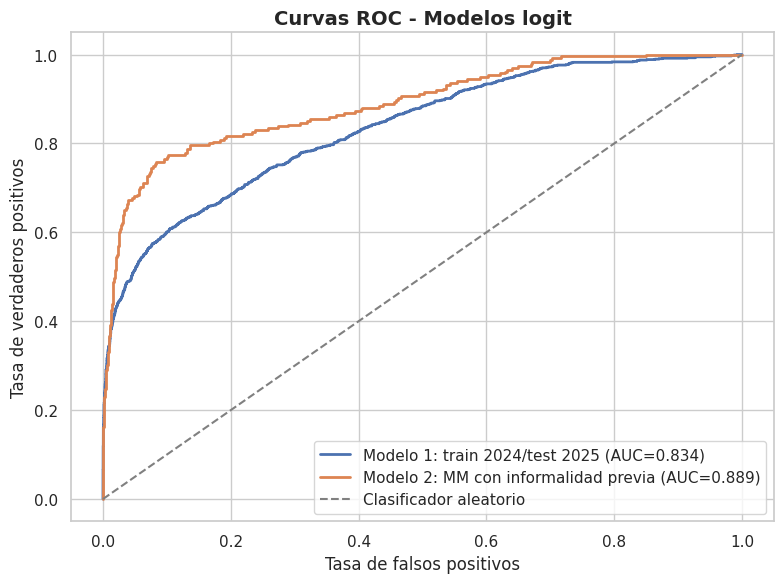

In [23]:
# ============================================================
# Celda 20 - Curvas ROC de ambos modelos
# ============================================================

fpr_m1, tpr_m1, _ = roc_curve(y_2025, prob_2025_modelo_2024)
fpr_m2, tpr_m2, _ = roc_curve(y_2025_MM, prob_2025_modelo_mm)

auc_m1 = roc_auc_score(y_2025, prob_2025_modelo_2024)
auc_m2 = roc_auc_score(y_2025_MM, prob_2025_modelo_mm)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_m1,
    tpr_m1,
    linewidth=2,
    label=f"Modelo 1: train 2024/test 2025 (AUC={auc_m1:.3f})"
)

plt.plot(
    fpr_m2,
    tpr_m2,
    linewidth=2,
    label=f"Modelo 2: MM con informalidad previa (AUC={auc_m2:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Clasificador aleatorio")

plt.title("Curvas ROC - Modelos logit", fontsize=14, fontweight="bold")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(loc="lower right")
plt.tight_layout()

plt.savefig(ruta_figuras + "TP3_Curvas_ROC_Modelos_Logit.png", dpi=300, bbox_inches="tight")
plt.show()


In [24]:
# ============================================================
# Celda 21 - Tabla comparativa de métricas
# ============================================================

tabla_metricas = pd.concat([metricas_m1, metricas_m2], ignore_index=True).round(4)

display(tabla_metricas)

tabla_metricas.to_excel(
    ruta_tablas + "TP3_Metricas_Modelos_Logit.xlsx",
    index=False
)


,modelo,umbral,accuracy,precision,recall,f1_score,auc
0,Modelo 1 - Logit 2024 aplicado a 2025,0.5000,0.9301,0.8873,0.2513,0.3917,0.8342
1,Modelo 2 - Logit MM con informalidad 2024,0.5000,0.9437,0.7317,0.3830,0.5028,0.8895


In [25]:
# ============================================================
# Celda 22 - Exportar bases y resultados adicionales
# ============================================================

# Exportar matrices X e y principales.
ocupados_X_2024.to_csv(ruta_tablas + "TP3_ocupados_X_2024.csv", index=False)
ocupados_X_2025.to_csv(ruta_tablas + "TP3_ocupados_X_2025.csv", index=False)
ocupados_X_2025_MM.to_csv(ruta_tablas + "TP3_ocupados_X_2025_MM.csv", index=False)

pd.DataFrame({"y_2024": y_2024}).to_csv(ruta_tablas + "TP3_y_2024.csv", index=False)
pd.DataFrame({"y_2025": y_2025}).to_csv(ruta_tablas + "TP3_y_2025.csv", index=False)
pd.DataFrame({"y_2025_MM": y_2025_MM}).to_csv(ruta_tablas + "TP3_y_2025_MM.csv", index=False)

# Exportar probabilidades predichas
predicciones_m1 = pd.DataFrame({
    "y_2025_observado": y_2025.values,
    "prob_modelo1": prob_2025_modelo_2024,
    "pred_modelo1_umbral_05": y_pred_m1
})

predicciones_m2 = pd.DataFrame({
    "y_2025_MM_observado": y_2025_MM.values,
    "prob_modelo2_MM": prob_2025_modelo_mm,
    "pred_modelo2_umbral_05": y_pred_m2
})

predicciones_m1.to_excel(ruta_tablas + "TP3_Predicciones_Modelo1.xlsx", index=False)
predicciones_m2.to_excel(ruta_tablas + "TP3_Predicciones_Modelo2_MM.xlsx", index=False)

print("Exportaciones adicionales guardadas.")


Exportaciones adicionales guardadas.


In [26]:
import os
import shutil

ORIGEN = "/content/drive/MyDrive/taller_de_programacion/"
DESTINO = "/content/Taller_de_Programacion_UBA/TP3/salidas"

os.makedirs(DESTINO, exist_ok=True)

for archivo in os.listdir(ORIGEN):
    origen = os.path.join(ORIGEN, archivo)
    destino = os.path.join(DESTINO, archivo)

    if os.path.isfile(origen):
        shutil.copy2(origen, destino)

print("Salidas copiadas al repositorio.")

Salidas copiadas al repositorio.


In [27]:
# ============================================================
# COPIAR SALIDAS DEL DRIVE AL REPOSITORIO GITHUB
# ============================================================

import os
import shutil

# Carpeta donde el TP3 genera actualmente las salidas
ORIGEN = "/content/drive/MyDrive/taller_de_programacion/salidas_tp3"

# Carpeta donde queremos que aparezcan en GitHub
DESTINO = "/content/Taller_de_Programacion_UBA/TP3/salidas"

# Crear carpeta destino
os.makedirs(DESTINO, exist_ok=True)

# Copiar figuras
origen_figuras = os.path.join(ORIGEN, "figuras")
destino_figuras = os.path.join(DESTINO, "figuras")

if os.path.exists(origen_figuras):
    shutil.copytree(
        origen_figuras,
        destino_figuras,
        dirs_exist_ok=True
    )

# Copiar tablas
origen_tablas = os.path.join(ORIGEN, "tablas")
destino_tablas = os.path.join(DESTINO, "tablas")

if os.path.exists(origen_tablas):
    shutil.copytree(
        origen_tablas,
        destino_tablas,
        dirs_exist_ok=True
    )

print("✅ Salidas copiadas al repositorio.")

✅ Salidas copiadas al repositorio.


In [28]:
# Ver archivos que serán enviados a GitHub

!find TP3/salidas -type f

TP3/salidas/tablas/TP3_y_2025.csv
TP3/salidas/tablas/TP3_Balance_Table_Train_2024_vs_Test_2025.xlsx
TP3/salidas/tablas/TP3_ocupados_X_2025.csv
TP3/salidas/tablas/TP3_y_2025_MM.csv
TP3/salidas/tablas/TP3_ocupados_X_2025_MM.csv
TP3/salidas/tablas/TP3_y_2024.csv
TP3/salidas/tablas/TP3_Predicciones_Modelo1.xlsx
TP3/salidas/tablas/TP3_ocupados_X_2024.csv
TP3/salidas/tablas/TP3_Checklist_Cumplimiento.xlsx
TP3/salidas/tablas/TP3_Predicciones_Modelo2_MM.xlsx
TP3/salidas/tablas/TP3_Metricas_Modelos_Logit.xlsx
TP3/salidas/tablas/TP3_Tabla_Modelos_Logit_Coef_SE_OR.xlsx
TP3/salidas/usu_individual_T425.xlsx
TP3/salidas/usu_individual_T424.xlsx
TP3/salidas/figuras/TP3_Matriz_Confusion_Modelo2_MM.png
TP3/salidas/figuras/TP3_Curvas_ROC_Modelos_Logit.png
TP3/salidas/figuras/TP3_Probabilidad_Predicha_Informalidad_vs_Educacion.png
TP3/salidas/figuras/TP3_Matriz_Confusion_Modelo1.png


In [29]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   TP3/salidas/figuras/TP3_Curvas_ROC_Modelos_Logit.png
	modified:   TP3/salidas/figuras/TP3_Matriz_Confusion_Modelo1.png
	modified:   TP3/salidas/figuras/TP3_Matriz_Confusion_Modelo2_MM.png
	modified:   TP3/salidas/figuras/TP3_Probabilidad_Predicha_Informalidad_vs_Educacion.png
	modified:   TP3/salidas/tablas/TP3_Balance_Table_Train_2024_vs_Test_2025.xlsx
	modified:   TP3/salidas/tablas/TP3_Metricas_Modelos_Logit.xlsx
	modified:   TP3/salidas/tablas/TP3_Predicciones_Modelo1.xlsx
	modified:   TP3/salidas/tablas/TP3_Predicciones_Modelo2_MM.xlsx
	modified:   TP3/salidas/tablas/TP3_Tabla_Modelos_Logit_Coef_SE_OR.xlsx
	modified:   TP3/salidas/tablas/TP3_ocupados_X_2024.csv
	modified:   TP3/salidas/tablas/TP3_ocupados_X_2025.csv
	modified:   TP3/salidas/tabla

In [30]:
!git add TP3/salidas
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	modified:   TP3/salidas/figuras/TP3_Curvas_ROC_Modelos_Logit.png
	modified:   TP3/salidas/figuras/TP3_Matriz_Confusion_Modelo1.png
	modified:   TP3/salidas/figuras/TP3_Matriz_Confusion_Modelo2_MM.png
	modified:   TP3/salidas/figuras/TP3_Probabilidad_Predicha_Informalidad_vs_Educacion.png
	modified:   TP3/salidas/tablas/TP3_Balance_Table_Train_2024_vs_Test_2025.xlsx
	modified:   TP3/salidas/tablas/TP3_Metricas_Modelos_Logit.xlsx
	modified:   TP3/salidas/tablas/TP3_Predicciones_Modelo1.xlsx
	modified:   TP3/salidas/tablas/TP3_Predicciones_Modelo2_MM.xlsx
	modified:   TP3/salidas/tablas/TP3_Tabla_Modelos_Logit_Coef_SE_OR.xlsx
	modified:   TP3/salidas/tablas/TP3_ocupados_X_2024.csv
	modified:   TP3/salidas/tablas/TP3_ocupados_X_2025.csv
	modified:   TP3/salidas/tablas/TP3_ocupados_X_2025_MM.csv



## conexión con github

In [31]:
!git config user.name "achasinavas"
!git config user.email "andrechna@gmail.com"

!git commit -m "Agregar salidas del TP3"

[main d0c48c1] Agregar salidas del TP3
 12 files changed, 25804 insertions(+), 25804 deletions(-)
 rewrite TP3/salidas/figuras/TP3_Curvas_ROC_Modelos_Logit.png (96%)
 rewrite TP3/salidas/figuras/TP3_Matriz_Confusion_Modelo1.png (67%)
 rewrite TP3/salidas/figuras/TP3_Matriz_Confusion_Modelo2_MM.png (66%)
 rewrite TP3/salidas/figuras/TP3_Probabilidad_Predicha_Informalidad_vs_Educacion.png (86%)
 rewrite TP3/salidas/tablas/TP3_Predicciones_Modelo1.xlsx (95%)
 rewrite TP3/salidas/tablas/TP3_Predicciones_Modelo2_MM.xlsx (95%)
 rewrite TP3/salidas/tablas/TP3_ocupados_X_2024.csv (90%)
 rewrite TP3/salidas/tablas/TP3_ocupados_X_2025.csv (91%)
 rewrite TP3/salidas/tablas/TP3_ocupados_X_2025_MM.csv (97%)


In [32]:
from google.colab import userdata

token = userdata.get("GITHUB_TOKEN")

print("✅ Token encontrado correctamente")

✅ Token encontrado correctamente


In [33]:
from google.colab import userdata
import subprocess
import base64

# ============================================================
# AUTENTICACIÓN SEGURA CON GITHUB
# ============================================================

token = userdata.get("GITHUB_TOKEN")

usuario = "achasinavas"

credenciales = base64.b64encode(
    f"{usuario}:{token}".encode()
).decode()

# ============================================================
# PUSH A GITHUB
# ============================================================

resultado = subprocess.run(
    [
        "git",
        "-c",
        f"http.extraHeader=Authorization: Basic {credenciales}",
        "push",
        "origin",
        "main"
    ],
    cwd="/content/Taller_de_Programacion_UBA",
    capture_output=True,
    text=True
)

print(resultado.stdout)

if resultado.returncode == 0:
    print("✅ Archivos enviados correctamente a GitHub.")
else:
    print("❌ Ocurrió un error:")
    print(resultado.stderr)


✅ Archivos enviados correctamente a GitHub.
